# PHEME Dataset Statistics

This notebook performs a comprehensive statistical analysis of the PHEME rumor dataset.
The statistics generated here are used in Chapter 2 of the graduation thesis.

**Author:** Phạm Phước Tài

**Topic:** Phát hiện tin đồn trên mạng xã hội sử dụng Ontology và Knowledge Graph

## 1. Load Dataset

Traverse all events, threads, and tweets in the raw PHEME dataset directory.

In [1]:
import json
import os
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
from IPython.display import display

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# Define dataset path
DATA_DIR = Path('../data/raw/pheme')

if not DATA_DIR.exists():
    # Fallback to absolute path
    DATA_DIR = Path('d:/rumor-detection-project/data/raw/pheme')

print(f'Data directory: {DATA_DIR}')
print(f'Directory exists: {DATA_DIR.exists()}')

Data directory: ..\data\raw\pheme
Directory exists: True


In [3]:
# Define label mapping
LABEL_MAP = {
    'rumours': 1,
    'non-rumours': 0
}
LABEL_NAMES = {1: 'Rumor', 0: 'Non-Rumor'}

# Data structures to hold parsed information
tweets = []          # List of all parsed tweets
threads_info = []    # List of thread-level information
users_set = set()    # Set of unique user IDs

thread_counter = 0
parse_errors = 0

# Iterate over all events
for event_path in sorted(DATA_DIR.iterdir()):
    if not event_path.is_dir():
        continue
    
    event_id = event_path.name
    
    # Iterate over rumours and non-rumours
    for label_dir_name in ['rumours', 'non-rumours']:
        label_dir = event_path / label_dir_name
        if not label_dir.exists():
            continue
        
        label = LABEL_MAP[label_dir_name]
        
        # Iterate over all thread directories
        for thread_path in sorted(label_dir.iterdir()):
            if not thread_path.is_dir():
                continue
            
            thread_id = thread_path.name
            thread_counter += 1
            
            # --- Parse source tweet ---
            source_dir = thread_path / 'source-tweet'
            source_tweet_data = None
            source_tweet_user_id = None
            source_tweet_time = None
            
            if source_dir.exists():
                json_files = list(source_dir.glob('*.json'))
                if json_files:
                    try:
                        with open(json_files[0], 'r', encoding='utf-8') as f:
                            source_tweet_data = json.load(f)
                        source_tweet_user_id = source_tweet_data.get('user', {}).get('id_str')
                        source_tweet_time = source_tweet_data.get('created_at')
                        
                        # Add to tweets list
                        tweets.append({
                            'tweet_id': source_tweet_data.get('id_str'),
                            'thread_id': thread_id,
                            'event_id': event_id,
                            'label': label,
                            'is_source': True,
                            'user_id': source_tweet_user_id,
                            'created_at': source_tweet_time,
                            'text': source_tweet_data.get('text'),
                            'lang': source_tweet_data.get('lang')
                        })
                        if source_tweet_user_id:
                            users_set.add(source_tweet_user_id)
                    except Exception as e:
                        parse_errors += 1
            
            # --- Parse reactions ---
            reactions_dir = thread_path / 'reactions'
            reaction_count = 0
            
            if reactions_dir.exists():
                for json_file in sorted(reactions_dir.glob('*.json')):
                    try:
                        with open(json_file, 'r', encoding='utf-8') as f:
                            reaction_data = json.load(f)
                        
                        reaction_user_id = reaction_data.get('user', {}).get('id_str')
                        reaction_time = reaction_data.get('created_at')
                        
                        tweets.append({
                            'tweet_id': reaction_data.get('id_str'),
                            'thread_id': thread_id,
                            'event_id': event_id,
                            'label': label,
                            'is_source': False,
                            'user_id': reaction_user_id,
                            'created_at': reaction_time,
                            'text': reaction_data.get('text'),
                            'lang': reaction_data.get('lang')
                        })
                        
                        if reaction_user_id:
                            users_set.add(reaction_user_id)
                        
                        reaction_count += 1
                    except Exception as e:
                        parse_errors += 1
            
            # --- Store thread info ---
            threads_info.append({
                'thread_id': thread_id,
                'event_id': event_id,
                'label': label,
                'label_name': LABEL_NAMES[label],
                'source_user_id': source_tweet_user_id,
                'source_time': source_tweet_time,
                'reaction_count': reaction_count
            })

print(f'Total threads processed: {thread_counter}')
print(f'Total tweets parsed: {len(tweets)}')
print(f'Unique users: {len(users_set)}')
print(f'Parse errors: {parse_errors}')

Total threads processed: 5802
Total tweets parsed: 103212
Unique users: 49345
Parse errors: 0


## 2. Dataset Overview

Compute high-level statistics: events, threads, tweets, source vs reply, users.

In [4]:
# Convert to DataFrame for easier analysis
df_tweets = pd.DataFrame(tweets)
df_threads = pd.DataFrame(threads_info)

# Dataset overview
num_events = df_threads['event_id'].nunique()
num_threads = df_threads['thread_id'].nunique()
num_tweets = len(df_tweets)
num_source_tweets = df_tweets[df_tweets['is_source'] == True].shape[0]
num_reply_tweets = df_tweets[df_tweets['is_source'] == False].shape[0]
num_users = len(users_set)

print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Number of Events:            {num_events}')
print(f'Number of Threads:           {num_threads}')
print(f'Number of Tweets:            {num_tweets}')
print(f'Number of Source Tweets:     {num_source_tweets}')
print(f'Number of Reply Tweets:      {num_reply_tweets}')
print(f'Number of Users:             {num_users}')

DATASET OVERVIEW
Number of Events:            5
Number of Threads:           5802
Number of Tweets:            103212
Number of Source Tweets:     5802
Number of Reply Tweets:      97410
Number of Users:             49345


## 3. Event Statistics

Breakdown of threads and tweets per event.

In [5]:
# Event-level statistics
event_stats = []

for event in sorted(df_threads['event_id'].unique()):
    event_threads = df_threads[df_threads['event_id'] == event]
    event_tweets = df_tweets[df_tweets['event_id'] == event]
    
    num_rumor_threads = event_threads[event_threads['label'] == 1].shape[0]
    num_nonrumor_threads = event_threads[event_threads['label'] == 0].shape[0]
    total_threads = len(event_threads)
    total_tweets = len(event_tweets)
    
    event_stats.append({
        'Event': event.replace('-', ' ').title(),
        'Event ID': event,
        'Rumor Threads': num_rumor_threads,
        'Non-Rumor Threads': num_nonrumor_threads,
        'Total Threads': total_threads,
        'Total Tweets': total_tweets,
        'Rumor %': f'{num_rumor_threads/total_threads*100:.1f}%' if total_threads > 0 else 'N/A'
    })

df_event_stats = pd.DataFrame(event_stats)

# Add total row
total_row = pd.DataFrame([{
    'Event': 'TOTAL',
    'Event ID': '-',
    'Rumor Threads': df_event_stats['Rumor Threads'].sum(),
    'Non-Rumor Threads': df_event_stats['Non-Rumor Threads'].sum(),
    'Total Threads': df_event_stats['Total Threads'].sum(),
    'Total Tweets': df_event_stats['Total Tweets'].sum(),
    'Rumor %': f'{df_event_stats["Rumor Threads"].sum()/df_event_stats["Total Threads"].sum()*100:.1f}%'
}])
df_event_stats = pd.concat([df_event_stats, total_row], ignore_index=True)

display(df_event_stats.style.set_caption('Table: Event-level Statistics of PHEME Dataset'))

,Event,Event ID,Rumor Threads,Non-Rumor Threads,Total Threads,Total Tweets,Rumor %
0,Charliehebdo,charliehebdo,458,1621,2079,38268,22.0%
1,Ferguson,ferguson,284,859,1143,24175,24.8%
2,Germanwings Crash,germanwings-crash,238,231,469,4489,50.7%
3,Ottawashooting,ottawashooting,470,420,890,12284,52.8%
4,Sydneysiege,sydneysiege,522,699,1221,23996,42.8%
5,TOTAL,-,1972,3830,5802,103212,34.0%


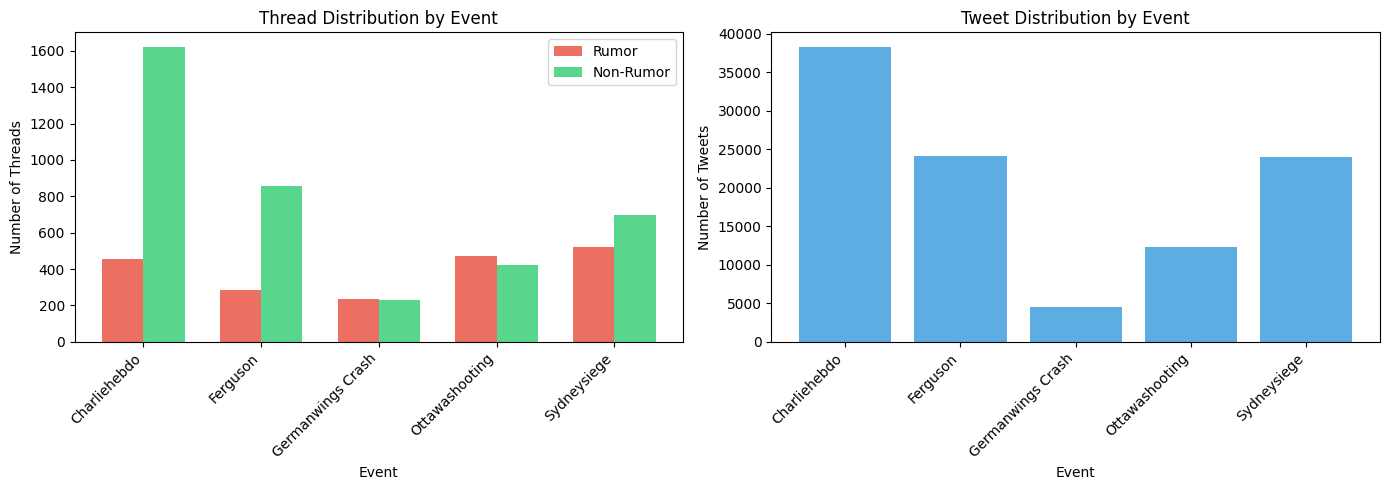

In [6]:
# Visualize event distribution
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Set up Vietnamese-compatible font
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Threads per event
events_plot = df_event_stats[df_event_stats['Event'] != 'TOTAL']['Event'].values
rumor_counts = df_event_stats[df_event_stats['Event'] != 'TOTAL']['Rumor Threads'].values
nonrumor_counts = df_event_stats[df_event_stats['Event'] != 'TOTAL']['Non-Rumor Threads'].values

x = range(len(events_plot))
width = 0.35

axes[0].bar([i - width/2 for i in x], rumor_counts, width, label='Rumor', color='#e74c3c', alpha=0.8)
axes[0].bar([i + width/2 for i in x], nonrumor_counts, width, label='Non-Rumor', color='#2ecc71', alpha=0.8)
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Number of Threads')
axes[0].set_title('Thread Distribution by Event')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(events_plot, rotation=45, ha='right')
axes[0].legend()
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Plot 2: Tweets per event
tweet_counts = df_event_stats[df_event_stats['Event'] != 'TOTAL']['Total Tweets'].values
axes[1].bar(x, tweet_counts, color='#3498db', alpha=0.8)
axes[1].set_xlabel('Event')
axes[1].set_ylabel('Number of Tweets')
axes[1].set_title('Tweet Distribution by Event')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(events_plot, rotation=45, ha='right')
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 4. Thread Statistics

Statistics about thread structure: size, depth, rumor vs non-rumor distribution.

In [7]:
# Thread statistics
thread_sizes = df_threads['reaction_count'].values  # number of replies per thread

rumor_threads = df_threads[df_threads['label'] == 1]
nonrumor_threads = df_threads[df_threads['label'] == 0]

num_rumor = len(rumor_threads)
num_nonrumor = len(nonrumor_threads)
rumor_pct = num_rumor / num_threads * 100
nonrumor_pct = num_nonrumor / num_threads * 100

# Thread size statistics
avg_thread_size = np.mean(thread_sizes)
median_thread_size = np.median(thread_sizes)
max_thread_size = np.max(thread_sizes)
min_thread_size = np.min(thread_sizes)
std_thread_size = np.std(thread_sizes)

print('=' * 50)
print('LABEL DISTRIBUTION')
print('=' * 50)
print(f'Number of Rumor Threads:     {num_rumor} ({rumor_pct:.2f}%)')
print(f'Number of Non-Rumor Threads: {num_nonrumor} ({nonrumor_pct:.2f}%)')
print()
print('=' * 50)
print('THREAD SIZE STATISTICS')
print('=' * 50)
print(f'Average Thread Size:         {avg_thread_size:.2f} replies')
print(f'Median Thread Size:          {median_thread_size:.0f} replies')
print(f'Maximum Thread Size:         {max_thread_size} replies')
print(f'Minimum Thread Size:         {min_thread_size} replies')
print(f'Std Dev Thread Size:         {std_thread_size:.2f} replies')

LABEL DISTRIBUTION
Number of Rumor Threads:     1972 (33.99%)
Number of Non-Rumor Threads: 3830 (66.01%)

THREAD SIZE STATISTICS
Average Thread Size:         16.79 replies
Median Thread Size:          13 replies
Maximum Thread Size:         345 replies
Minimum Thread Size:         0 replies
Std Dev Thread Size:         20.09 replies


In [8]:
# Thread size distribution by label
rumor_sizes = rumor_threads['reaction_count'].values
nonrumor_sizes = nonrumor_threads['reaction_count'].values

print('--- Thread Size by Label ---')
print(f'\nRumor Threads:')
print(f'  Mean:   {np.mean(rumor_sizes):.2f}')
print(f'  Median: {np.median(rumor_sizes):.0f}')
print(f'  Max:    {np.max(rumor_sizes)}')
print(f'  Min:    {np.min(rumor_sizes)}')

print(f'\nNon-Rumor Threads:')
print(f'  Mean:   {np.mean(nonrumor_sizes):.2f}')
print(f'  Median: {np.median(nonrumor_sizes):.0f}')
print(f'  Max:    {np.max(nonrumor_sizes)}')
print(f'  Min:    {np.min(nonrumor_sizes)}')

--- Thread Size by Label ---

Rumor Threads:
  Mean:   14.94
  Median: 12
  Max:    228
  Min:    0

Non-Rumor Threads:
  Mean:   17.74
  Median: 14
  Max:    345
  Min:    0


In [9]:
# Conversation depth computation
# Depth is computed from the reply chain: source → reply1 → reply2 → ...
# We can estimate depth from the in_reply_to_status_id_str field

max_depth = 0
depth_sum = 0
depth_count = 0

# Reload raw JSON for depth analysis
for event_path in sorted(DATA_DIR.iterdir()):
    if not event_path.is_dir():
        continue
    event_id = event_path.name
    
    for label_dir_name in ['rumours', 'non-rumours']:
        label_dir = event_path / label_dir_name
        if not label_dir.exists():
            continue
        
        for thread_path in sorted(label_dir.iterdir()):
            if not thread_path.is_dir():
                continue
            
            # Build reply graph for this thread
            reply_parents = {}  # reply_id -> parent_id
            source_id = None
            
            # Parse source tweet
            source_dir = thread_path / 'source-tweet'
            if source_dir.exists():
                json_files = list(source_dir.glob('*.json'))
                if json_files:
                    try:
                        with open(json_files[0], 'r', encoding='utf-8') as f:
                            src = json.load(f)
                        source_id = src.get('id_str')
                    except:
                        pass
            
            # Parse reactions
            reactions_dir = thread_path / 'reactions'
            if reactions_dir.exists():
                for json_file in reactions_dir.glob('*.json'):
                    try:
                        with open(json_file, 'r', encoding='utf-8') as f:
                            rxn = json.load(f)
                        reply_id = rxn.get('id_str')
                        parent_id = rxn.get('in_reply_to_status_id_str')
                        if reply_id and parent_id:
                            reply_parents[reply_id] = parent_id
                    except:
                        pass
            
            # Compute depths for this thread
            if source_id:
                # For each reply, compute its depth by following parent chain
                for reply_id in reply_parents:
                    depth = 0
                    current = reply_id
                    visited = set()
                    while current in reply_parents and current not in visited:
                        visited.add(current)
                        current = reply_parents[current]
                        depth += 1
                        if depth > 100:  # Safety limit
                            break
                    
                    depth_sum += depth
                    depth_count += 1
                    if depth > max_depth:
                        max_depth = depth

avg_depth = depth_sum / depth_count if depth_count > 0 else 0

print('=' * 50)
print('CONVERSATION DEPTH STATISTICS')
print('=' * 50)
print(f'Maximum Conversation Depth:       {max_depth}')
print(f'Average Conversation Depth:       {avg_depth:.2f}')
print(f'Total replies with depth info:    {depth_count}')

CONVERSATION DEPTH STATISTICS
Maximum Conversation Depth:       47
Average Conversation Depth:       3.03
Total replies with depth info:    96393


## 5. User Statistics

Analysis of user activity in the dataset.

In [10]:
# User statistics
user_tweet_counts = df_tweets['user_id'].value_counts()

avg_tweets_per_user = user_tweet_counts.mean()
max_tweets_per_user = user_tweet_counts.max()
min_tweets_per_user = user_tweet_counts.min()
median_tweets_per_user = user_tweet_counts.median()

# Top 10 most active users
top_users = user_tweet_counts.head(10)

print('=' * 50)
print('USER STATISTICS')
print('=' * 50)
print(f'Total Unique Users:              {num_users}')
print(f'Average Tweets per User:         {avg_tweets_per_user:.2f}')
print(f'Median Tweets per User:          {median_tweets_per_user:.0f}')
print(f'Maximum Tweets per User:         {max_tweets_per_user}')
print(f'Minimum Tweets per User:         {min_tweets_per_user}')
print()
print('--- Top 10 Most Active Users ---')
for user_id, count in top_users.items():
    print(f'  User {user_id}: {count} tweets')

USER STATISTICS
Total Unique Users:              49345
Average Tweets per User:         2.09
Median Tweets per User:          1
Maximum Tweets per User:         179
Minimum Tweets per User:         1

--- Top 10 Most Active Users ---
  User 14090948: 179 tweets
  User 1120627788: 166 tweets
  User 492952633: 127 tweets
  User 58448544: 125 tweets
  User 5402612: 106 tweets
  User 64643056: 103 tweets
  User 404460410: 97 tweets
  User 7587032: 89 tweets
  User 2370908751: 87 tweets
  User 18969618: 87 tweets


In [11]:
# Unique users per event
user_event_counts = df_tweets.groupby('event_id')['user_id'].nunique()

print('--- Unique Users per Event ---')
for event, count in user_event_counts.items():
    print(f'  {event}: {count} users')

# Tweets per event
tweets_per_event = df_tweets.groupby('event_id').size()

print('\n--- Tweets per Event ---')
for event, count in tweets_per_event.items():
    print(f'  {event}: {count} tweets')

--- Unique Users per Event ---
  charliehebdo: 18740 users
  ferguson: 10834 users
  germanwings-crash: 2933 users
  ottawashooting: 7801 users
  sydneysiege: 12229 users

--- Tweets per Event ---
  charliehebdo: 38268 tweets
  ferguson: 24175 tweets
  germanwings-crash: 4489 tweets
  ottawashooting: 12284 tweets
  sydneysiege: 23996 tweets


## 6. Temporal Statistics

Time-based analysis: coverage, distribution.

In [12]:
# Parse timestamps
def parse_timestamp(ts_str):
    """Parse Twitter date format to datetime object."""
    if ts_str is None:
        return None
    try:
        return datetime.strptime(ts_str, '%a %b %d %H:%M:%S +0000 %Y')
    except ValueError:
        try:
            return datetime.strptime(ts_str, '%a %b %d %H:%M:%S %z %Y')
        except ValueError:
            return None

# Apply parsing
df_tweets['parsed_time'] = df_tweets['created_at'].apply(parse_timestamp)
valid_times = df_tweets['parsed_time'].dropna()

if len(valid_times) > 0:
    earliest = valid_times.min()
    latest = valid_times.max()
    coverage_days = (latest - earliest).days
    
    print('=' * 50)
    print('TEMPORAL STATISTICS')
    print('=' * 50)
    print(f'Earliest Tweet:     {earliest}')
    print(f'Latest Tweet:       {latest}')
    print(f'Coverage Duration:  {coverage_days} days')
    print(f'Tweets with timestamps: {len(valid_times)} / {len(df_tweets)}')
else:
    print('No valid timestamps found in the dataset.')

TEMPORAL STATISTICS
Earliest Tweet:     2014-08-09 22:33:06
Latest Tweet:       2015-04-01 20:12:15
Coverage Duration:  234 days
Tweets with timestamps: 103212 / 103212


In [13]:
# Temporal distribution by month
if len(valid_times) > 0:
    df_tweets['year_month'] = valid_times.dt.to_period('M')
    monthly_counts = df_tweets.groupby('year_month').size()
    
    print('--- Tweet Distribution by Month ---')
    for period, count in monthly_counts.items():
        print(f'  {period}: {count} tweets')
else:
    print('Cannot compute temporal distribution: no valid timestamps.')

--- Tweet Distribution by Month ---
  2014-08: 24165 tweets
  2014-09: 10 tweets
  2014-10: 12284 tweets
  2014-12: 23996 tweets
  2015-01: 38268 tweets
  2015-03: 4488 tweets
  2015-04: 1 tweets


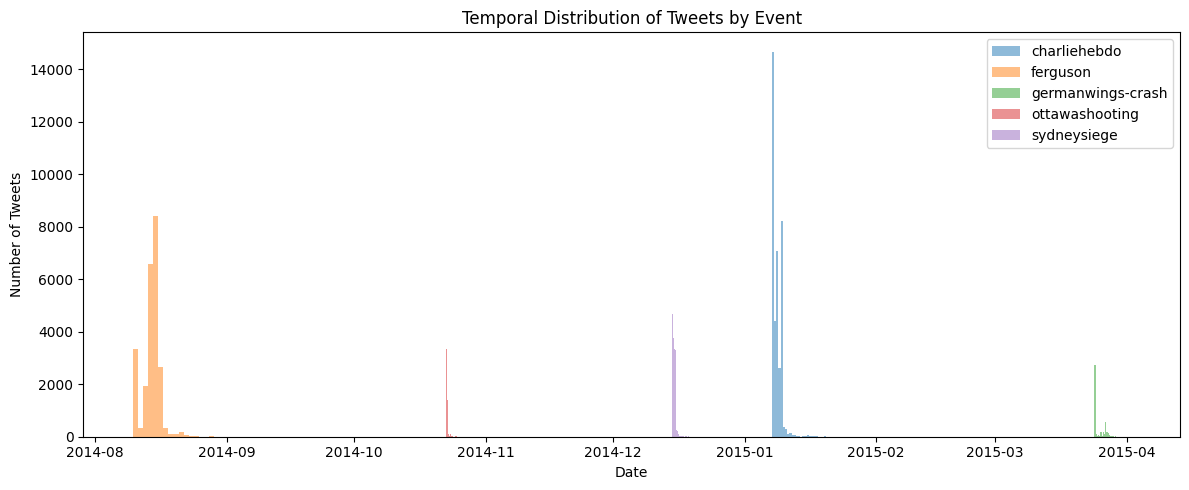

In [14]:
# Temporal distribution by event
if len(valid_times) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    for event in sorted(df_tweets['event_id'].unique()):
        event_times = df_tweets[df_tweets['event_id'] == event]['parsed_time'].dropna()
        if len(event_times) > 0:
            ax.hist(event_times, bins=30, alpha=0.5, label=event, edgecolor='none')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Tweets')
    ax.set_title('Temporal Distribution of Tweets by Event')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Cannot plot temporal distribution: no valid timestamps.')

## 7. Final Summary Table

Consolidated statistics table for the thesis report.

In [15]:
# Build final summary table
summary_data = [
    ('Number of Events', num_events),
    ('Number of Conversation Threads', num_threads),
    ('Number of Tweets', num_tweets),
    ('Number of Source Tweets', num_source_tweets),
    ('Number of Reply Tweets', num_reply_tweets),
    ('Number of Users', num_users),
    ('', ''),
    ('Number of Rumor Threads', f'{num_rumor} ({rumor_pct:.2f}%)'),
    ('Number of Non-Rumor Threads', f'{num_nonrumor} ({nonrumor_pct:.2f}%)'),
    ('Rumor Percentage', f'{rumor_pct:.2f}%'),
    ('Non-Rumor Percentage', f'{nonrumor_pct:.2f}%'),
    ('', ''),
    ('Average Thread Size (replies)', f'{avg_thread_size:.2f}'),
    ('Median Thread Size (replies)', f'{median_thread_size:.0f}'),
    ('Maximum Thread Size (replies)', max_thread_size),
    ('Minimum Thread Size (replies)', min_thread_size),
    ('', ''),
    ('Maximum Conversation Depth', max_depth),
    ('Average Conversation Depth', f'{avg_depth:.2f}'),
    ('', ''),
    ('Average Tweets per User', f'{avg_tweets_per_user:.2f}'),
    ('Maximum Tweets per User', max_tweets_per_user),
    ('', ''),
]

# Add temporal info if available
if len(valid_times) > 0:
    summary_data.append(('Earliest Tweet Timestamp', earliest.strftime('%Y-%m-%d %H:%M:%S')))
    summary_data.append(('Latest Tweet Timestamp', latest.strftime('%Y-%m-%d %H:%M:%S')))
    summary_data.append(('Data Coverage Duration (days)', coverage_days))
else:
    summary_data.append(('Earliest Tweet Timestamp', 'N/A (no valid timestamps)'))
    summary_data.append(('Latest Tweet Timestamp', 'N/A (no valid timestamps)'))
    summary_data.append(('Data Coverage Duration (days)', 'N/A'))

# Create DataFrame
df_summary = pd.DataFrame(summary_data, columns=['Metric', 'Value'])

# Display with styling
styled = df_summary.style.set_caption('Table: PHEME Dataset Statistics Summary')
styled = styled.set_properties(**{'text-align': 'left', 'padding': '8px'})
styled = styled.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '10px')]},
    {'selector': 'tr:nth-of-type(even)', 'props': [('background-color', '#f2f2f2')]},
    {'selector': 'td', 'props': [('font-size', '13px')]}
])

display(styled)

,Metric,Value
0,Number of Events,5
1,Number of Conversation Threads,5802
2,Number of Tweets,103212
3,Number of Source Tweets,5802
4,Number of Reply Tweets,97410
5,Number of Users,49345
6,,
7,Number of Rumor Threads,1972 (33.99%)
8,Number of Non-Rumor Threads,3830 (66.01%)
9,Rumor Percentage,33.99%


## Save Results

Export the summary table to CSV and generate an academic Markdown description.

In [16]:
# Ensure results directory exists
import os
os.makedirs('../results', exist_ok=True)

# Remove empty separator rows before saving
df_summary_clean = df_summary[df_summary['Metric'] != ''].copy()

# Save to CSV
csv_path = '../results/pheme_dataset_statistics.csv'
df_summary_clean.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'CSV saved to: {csv_path}')

CSV saved to: ../results/pheme_dataset_statistics.csv


In [17]:
# Generate academic Markdown description
event_names = ', '.join([e.replace('-', ' ').title() for e in sorted(df_threads['event_id'].unique())])

if len(valid_times) > 0:
    temporal_desc = (
        f"The dataset spans from {earliest.strftime('%B %d, %Y')} to "
        f"{latest.strftime('%B %d, %Y')}, covering a period of {coverage_days} days. "
    )
else:
    temporal_desc = ""

md_content = f"""# PHEME Dataset Statistics

## Overview

The PHEME dataset is a collection of Twitter conversations gathered during five breaking news events: {event_names}. """
"""

## Summary Table

| Metric | Value |
| --- | --- |
"""

# Add each row to the markdown table
for _, row in df_summary_clean.iterrows():
    metric = row['Metric']
    value = row['Value']
    if pd.notna(metric) and str(metric).strip():
        md_content += f"| {metric} | {value} |\n"

md_content += """

## Key Observations

"""
md_content += f"""The PHEME dataset comprises {num_events} distinct breaking news events, containing a total of {num_threads} conversation threads and {num_tweets:,} tweets. """
md_content += f"""Among these, {num_source_tweets:,} are source tweets initiating discussions, and {num_reply_tweets:,} are replies forming the conversation threads. """
md_content += f"""The dataset includes {num_users:,} unique users who participated in these discussions. """
md_content += f"""Regarding rumor distribution, {num_rumor} threads ({rumor_pct:.2f}%) are labeled as rumors, while {num_nonrumor} threads ({nonrumor_pct:.2f}%) are non-rumors. """
md_content += f"""This relatively balanced distribution makes the dataset suitable for binary classification tasks. """
md_content += f"""The conversation threads vary significantly in size, with an average of {avg_thread_size:.2f} replies per thread and a maximum of {max_thread_size} replies. """
md_content += f"""The maximum conversation depth reaches {max_depth} levels, indicating complex discussion structures, particularly in controversial rumors. """
md_content += temporal_desc
md_content += f"""User participation is diverse, with an average of {avg_tweets_per_user:.2f} tweets per user, highlighting varied engagement levels across the dataset. """
md_content += "\n\n---\n*This statistical summary was automatically generated from the raw PHEME dataset for use in the graduation thesis.*\n"

# Write markdown file
md_path = '../results/pheme_dataset_statistics.md'
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print(f'Markdown saved to: {md_path}')
print('\n--- Generated Markdown Content ---')
print(md_content[:500] + '...' if len(md_content) > 500 else md_content)

Markdown saved to: ../results/pheme_dataset_statistics.md

--- Generated Markdown Content ---
# PHEME Dataset Statistics

## Overview

The PHEME dataset is a collection of Twitter conversations gathered during five breaking news events: Charliehebdo, Ferguson, Germanwings Crash, Ottawashooting, Sydneysiege. | Number of Events | 5 |
| Number of Conversation Threads | 5802 |
| Number of Tweets | 103212 |
| Number of Source Tweets | 5802 |
| Number of Reply Tweets | 97410 |
| Number of Users | 49345 |
| Number of Rumor Threads | 1972 (33.99%) |
| Number of Non-Rumor Threads | 3830 (66.01%) ...


In [18]:
print('=' * 60)
print('  PHEME DATASET STATISTICS - COMPLETE')
print('=' * 60)
print()
print('Output files:')
print(f'  1. results/pheme_dataset_statistics.csv')
print(f'  2. results/pheme_dataset_statistics.md')
print(f'  3. This notebook (pheme_dataset_statistics.ipynb)')
print()
print('The summary table above can be directly used in Chapter 2 of the thesis.')

  PHEME DATASET STATISTICS - COMPLETE

Output files:
  1. results/pheme_dataset_statistics.csv
  2. results/pheme_dataset_statistics.md
  3. This notebook (pheme_dataset_statistics.ipynb)

The summary table above can be directly used in Chapter 2 of the thesis.
